# scstability: which of your clusters are real?

A complete analysis of **11,000 human PBMCs**, from raw 10x output to a
clustering you could defend to a reviewer.

The question this package answers is narrow and specific:

> You ran Leiden. You got 20 clusters. **Which of them would still be there if
> you had sequenced a different sample of the same blood?**

Nothing in the clustering itself can tell you. Leiden returns clusters from
pure noise, confidently. The silhouette score rewards compactness — which a
slice carved out of a continuum also has. The only way to find out is to
resample the cells and recluster, which is what `scstability` does.

Everything below runs top to bottom in a few minutes.

In [1]:
import os
import pathlib
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import scstability as scs

warnings.simplefilter("ignore")
sc.settings.verbosity = 0
sc.set_figure_params(dpi=90, frameon=False, figsize=(5, 5))
pd.set_option("display.width", 200)

print("scstability", scs.__version__, "| scanpy", sc.__version__)

scstability 0.1.0.dev0 | scanpy 1.12.4


## 1. Load and preprocess

10x's public `pbmc_10k_v3` — peripheral blood mononuclear cells, v3 chemistry.
Nothing here is specific to `scstability`; it is the standard scanpy pipeline,
and the only thing the package needs from it is `adata.obsm["X_pca"]`.

In [2]:
CACHE = pathlib.Path(os.environ.get("SCSTABILITY_DATA", "data"))
path = CACHE / "pbmc_10k_v3.h5"
if not path.exists():
    CACHE.mkdir(parents=True, exist_ok=True)
    url = (
        "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_10k_v3/"
        "pbmc_10k_v3_filtered_feature_bc_matrix.h5"
    )
    req = urllib.request.Request(url, headers={"User-Agent": "curl/8.0"})
    with urllib.request.urlopen(req, timeout=1800) as r:
        path.write_bytes(r.read())

adata = sc.read_10x_h5(path)
adata.var_names_make_unique()
print(f"{adata.n_obs:,} droplets x {adata.n_vars:,} genes")

11,769 droplets x 33,538 genes


In [3]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
adata = adata[
    (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.n_genes_by_counts < 6000)
    & (adata.obs.pct_counts_mt < 20)
].copy()
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver="arpack", random_state=0)

sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca", random_state=0)
sc.tl.umap(adata, random_state=0)

print(f"{adata.n_obs:,} cells x {adata.n_vars:,} highly variable genes")
print("X_pca:", adata.obsm["X_pca"].shape)

11,037 cells x 2,000 highly variable genes
X_pca: (11037, 50)


## 2. The problem, made concrete

Two perfectly reasonable resolutions give different answers. Which one is
right?

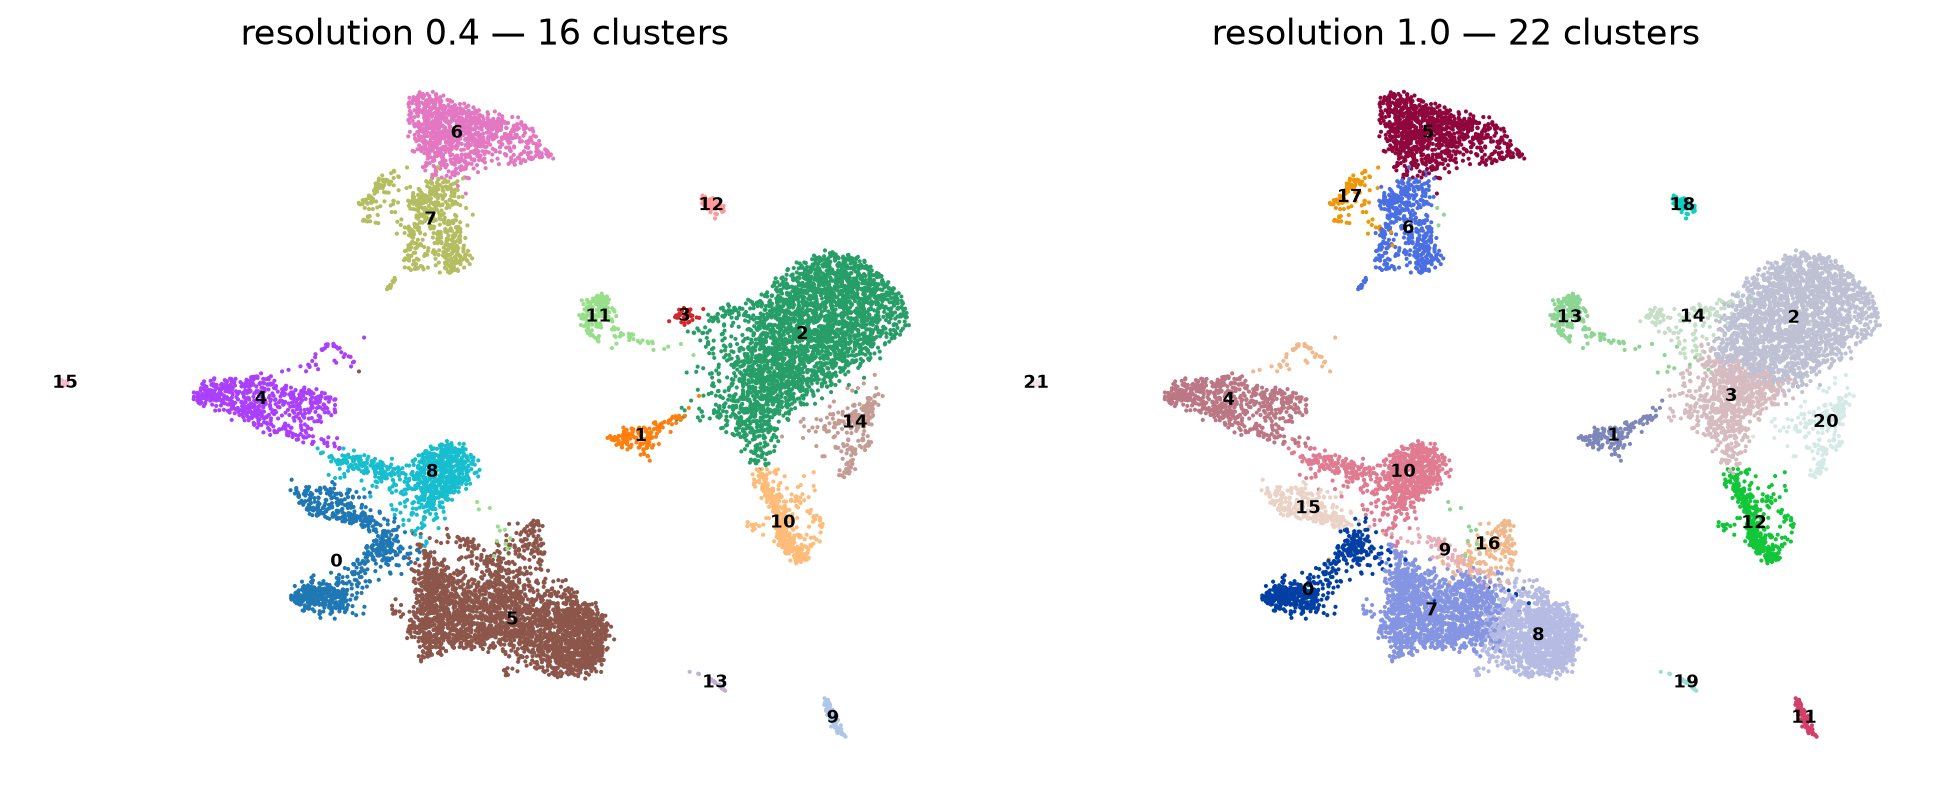

In [4]:
for res in (0.4, 1.0):
    sc.tl.leiden(
        adata,
        resolution=res,
        key_added=f"leiden_{res}",
        flavor="igraph",
        n_iterations=2,
        directed=False,
        random_state=0,
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
sc.pl.umap(
    adata,
    color="leiden_0.4",
    ax=axes[0],
    show=False,
    legend_loc="on data",
    legend_fontsize=7,
    title=f"resolution 0.4 — {adata.obs['leiden_0.4'].nunique()} clusters",
)
sc.pl.umap(
    adata,
    color="leiden_1.0",
    ax=axes[1],
    show=False,
    legend_loc="on data",
    legend_fontsize=7,
    title=f"resolution 1.0 — {adata.obs['leiden_1.0'].nunique()} clusters",
)
plt.tight_layout()
plt.show()

Both look plausible. Both are publishable. They disagree about how many
populations are in this blood sample.

## 3. Run the stability sweep

One call. It reclusters a random 80% of the cells, 30 times, at each
resolution, and measures how much of each original cluster comes back together.

In [5]:
result = scs.stability_sweep(
    adata,
    resolutions=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.4],
    n_boot=30,
    frac=0.8,
    random_state=0,
    progress=False,
)
result.summary()

,resolution,n_clusters,min_cluster_stability,median_cluster_stability,frac_cells_stable
0,0.1,8,0.637927,0.901436,0.890641
1,0.2,12,0.178555,0.941740,0.992208
2,0.4,16,0.532285,0.963386,0.988493
3,0.6,18,0.462027,0.968739,0.855395
4,0.8,20,0.681286,0.965009,0.883845
5,1.0,22,0.498528,0.936524,0.881399
6,1.4,26,0.104897,0.905739,0.852677


**Read `min_cluster_stability`, not the median.** A resolution is only as
trustworthy as its weakest cluster, and the gap between the two columns is
the whole point: at resolution 0.2 the typical cluster scores 0.94 while the
worst scores 0.18.

In [6]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    chosen = result.recommend()

print(f"recommend() -> {chosen}")
for w in caught:
    print(f"\nWARNING: {w.message}")

recommend() -> 0.8



That warning is the honest answer. **Real blood has no resolution at which
every cluster is trustworthy.** The tool does not pretend otherwise; it
returns the best available and tells you it is below the bar.

## 4. The stability curve

Every dot is a cluster. The black line follows the weakest one at each
resolution — the number that decides whether you can trust the whole
partition.

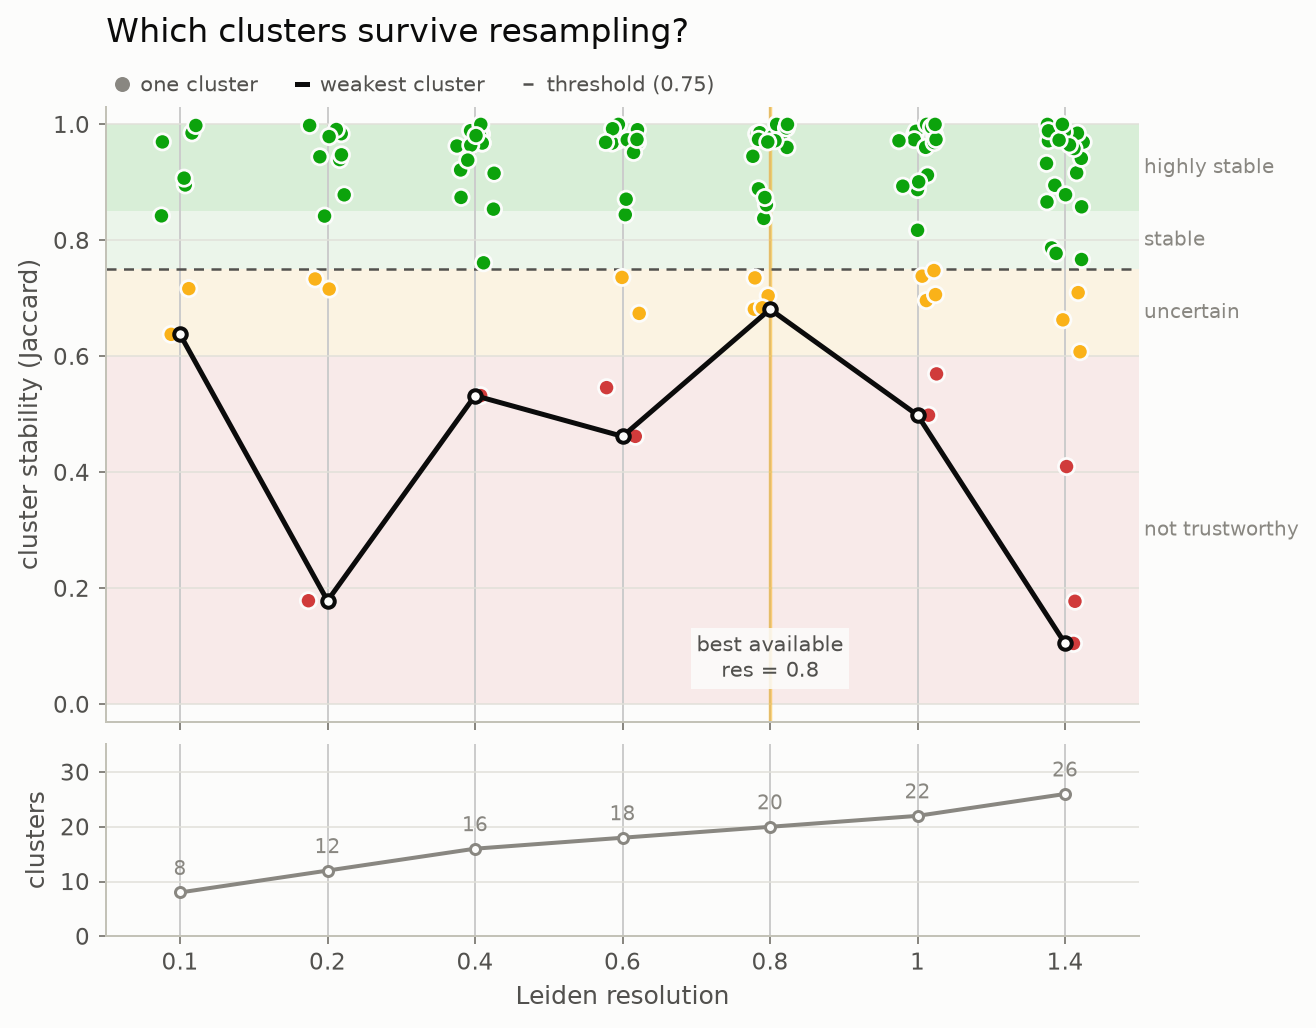

In [7]:
fig = scs.pl.stability_curve(result)
plt.show()

## 5. Which clusters specifically?

Sorted weakest first, because those are the ones you need to read.

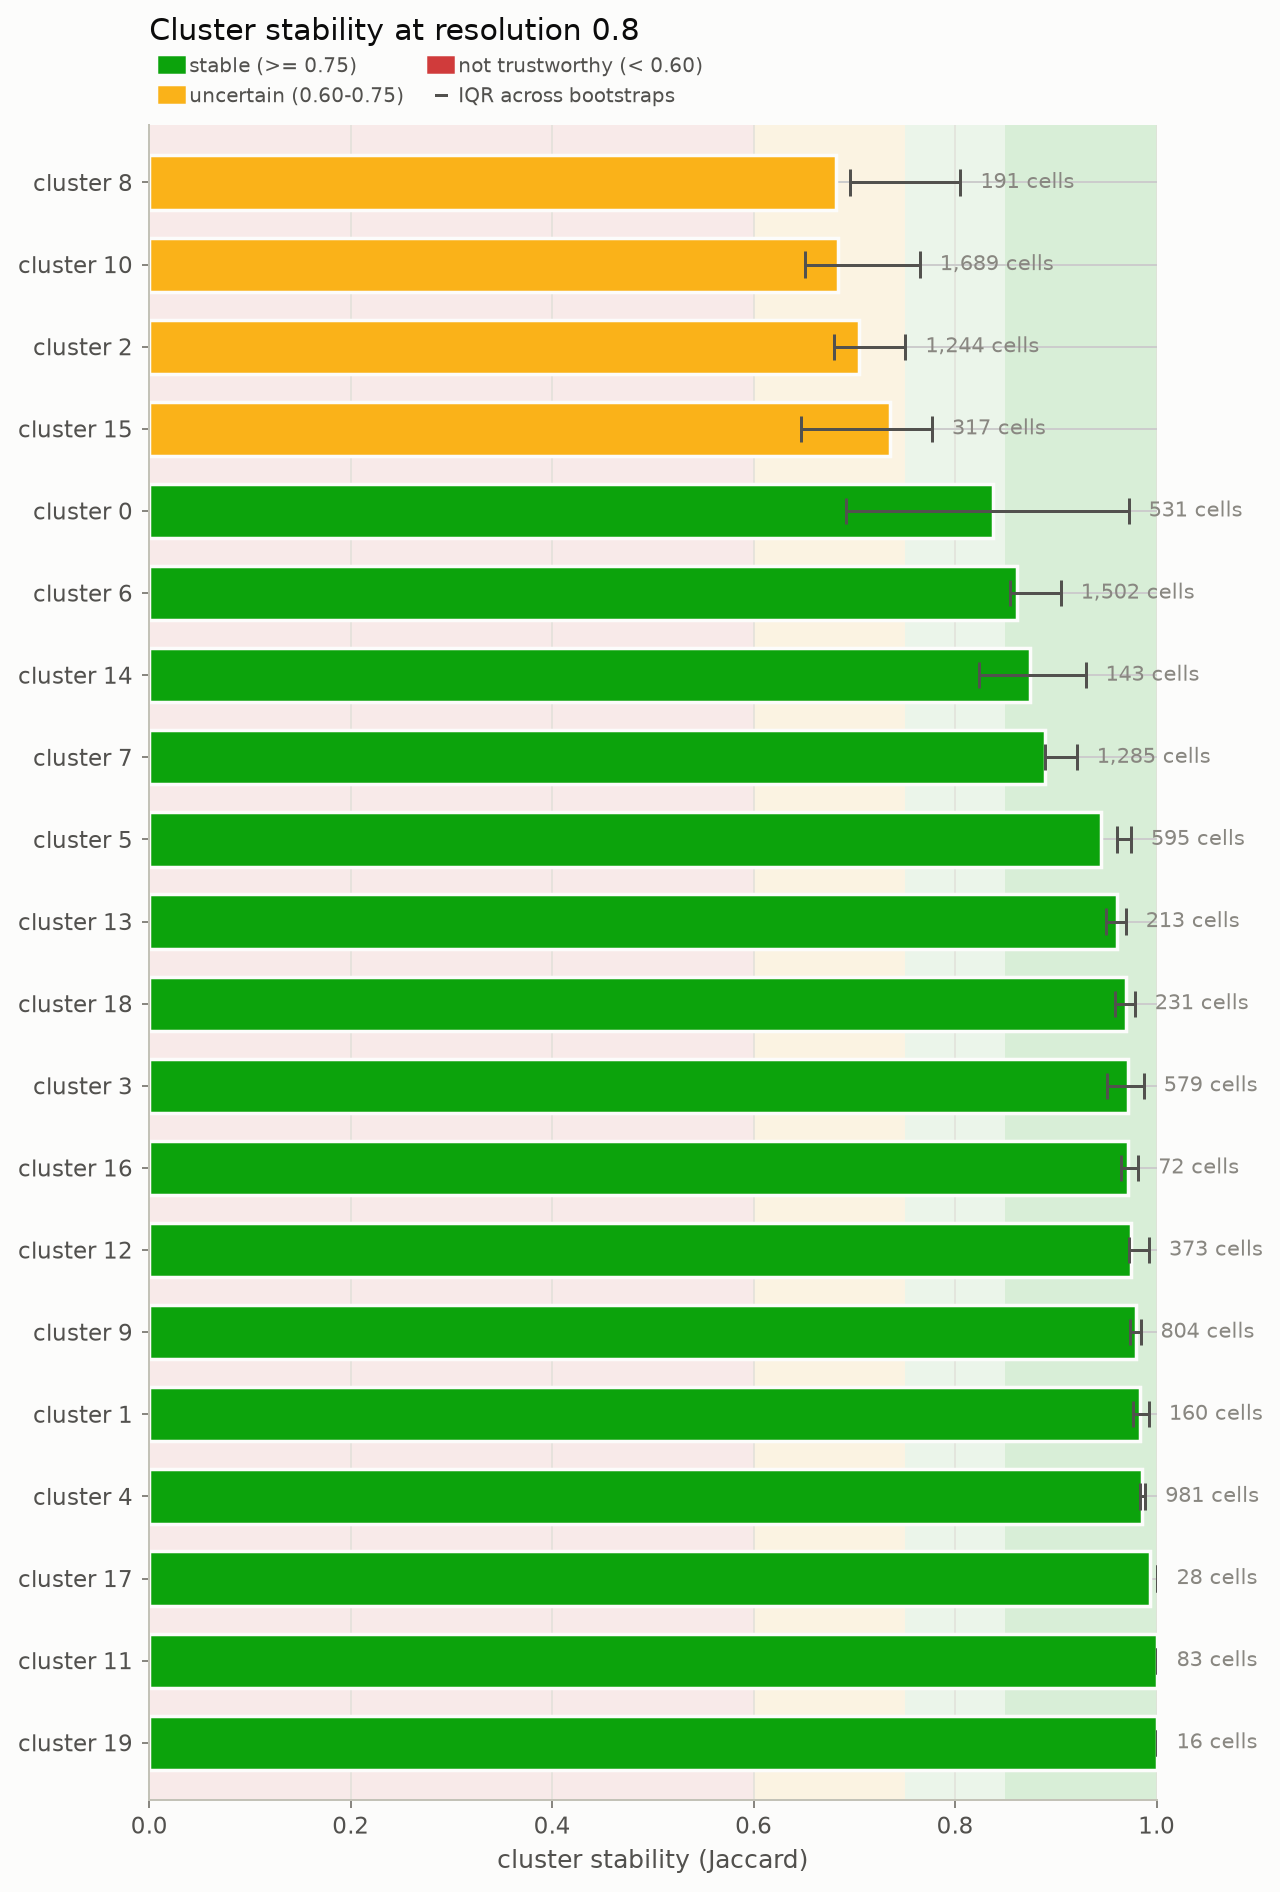

In [8]:
sc.tl.leiden(
    adata,
    resolution=chosen,
    key_added="leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=0,
)

ax = scs.pl.cluster_stability(result, resolution=chosen)
plt.show()

## 6. What are these clusters, biologically?

The package knows nothing about biology — it sees 50 PCA coordinates. So the
marker panels below are an *independent* check on whether the stable clusters
are the real populations.

In [9]:
MARKERS = {
    "T cells": ["CD3D", "CD3E", "IL7R"],
    "CD8 T / NK": ["CD8A", "GNLY", "NKG7"],
    "B cells": ["CD79A", "MS4A1"],
    "Monocytes (CD14)": ["CD14", "LYZ", "S100A8"],
    "Monocytes (FCGR3A)": ["FCGR3A", "MS4A7"],
    "Dendritic": ["FCER1A", "CST3"],
    "Platelets": ["PPBP", "PF4"],
}

panels = {}
for name, genes in MARKERS.items():
    present = [g for g in genes if g in adata.raw.var_names]
    v = adata.raw[:, present].X
    v = np.asarray(v.todense() if hasattr(v, "todense") else v)
    panels[name] = pd.Series(v.mean(axis=1), index=adata.obs_names)

by_cluster = pd.DataFrame(panels).groupby(adata.obs["leiden"].astype(str).values).mean()

# Absolute expression, with an explicit "unassigned" floor. Do NOT z-score:
# that guarantees every panel wins somewhere, so a cluster matching nothing
# still gets a confident label.
best = by_cluster.max(axis=1)
identity = by_cluster.idxmax(axis=1).where(best >= 0.5, "unassigned")

adata.obs["cell_type"] = (
    adata.obs["leiden"].astype(str).map(identity).astype("category")
)
by_cluster.round(2)

,T cells,CD8 T / NK,B cells,Monocytes (CD14),Monocytes (FCGR3A),Dendritic,Platelets
0,1.80,0.69,0.10,0.37,0.03,0.06,0.04
1,0.05,0.10,0.05,2.03,0.22,2.81,0.03
10,0.04,0.08,0.03,3.72,0.58,1.57,0.06
11,0.10,0.17,0.18,0.49,0.05,1.69,0.09
12,0.08,0.16,0.07,1.34,2.61,1.53,0.04
13,0.22,0.11,0.08,1.24,0.16,1.03,4.87
14,0.06,0.09,0.02,3.94,0.59,1.54,0.04
15,1.44,1.92,0.06,0.48,0.22,0.09,0.04
16,0.06,0.07,1.53,3.54,0.43,1.33,0.07
17,0.10,0.07,0.14,0.32,0.03,0.65,0.00


In [10]:
block = result.cluster_stability
block = block[block.resolution == chosen].copy()
keys = block["cluster"].astype(str)
block["identity"] = keys.map(identity)
block["marker_level"] = keys.map(best.round(2))
block["verdict"] = pd.cut(
    block["jaccard_mean"],
    [0, 0.6, 0.75, 0.85, 1.0],
    labels=["NOT TRUSTWORTHY", "uncertain", "stable", "highly stable"],
)

block.sort_values("jaccard_mean", ascending=False)[
    [
        "cluster",
        "n_cells",
        "jaccard_mean",
        "jaccard_q25",
        "identity",
        "marker_level",
        "verdict",
    ]
].round(3).reset_index(drop=True)

,cluster,n_cells,jaccard_mean,jaccard_q25,identity,marker_level,verdict
0,19,16,1.000,1.000,Dendritic,2.19,highly stable
1,11,83,1.000,1.000,Dendritic,1.69,highly stable
2,17,28,0.994,1.000,Dendritic,0.65,highly stable
3,4,981,0.986,0.984,B cells,2.57,highly stable
4,1,160,0.984,0.977,Dendritic,2.81,highly stable
5,9,804,0.980,0.974,T cells,1.96,highly stable
6,12,373,0.974,0.972,Monocytes (FCGR3A),2.61,highly stable
7,16,72,0.972,0.965,Monocytes (CD14),3.54,highly stable
8,3,579,0.972,0.951,CD8 T / NK,3.00,highly stable
9,18,231,0.970,0.959,Monocytes (CD14),3.52,highly stable


The pattern is biologically sensible, and the package was told none of it:
the small distinct populations — platelets, dendritic cells, B cells — are
rock solid. The **CD14 monocyte compartment** is where stability collapses,
which is exactly where CD14⁺ and FCGR3A⁺ states grade into one another.

## 7. Where is the instability, on the map?

Three views of the same cells: the clusters, what they are, and how much you
can trust the assignment.

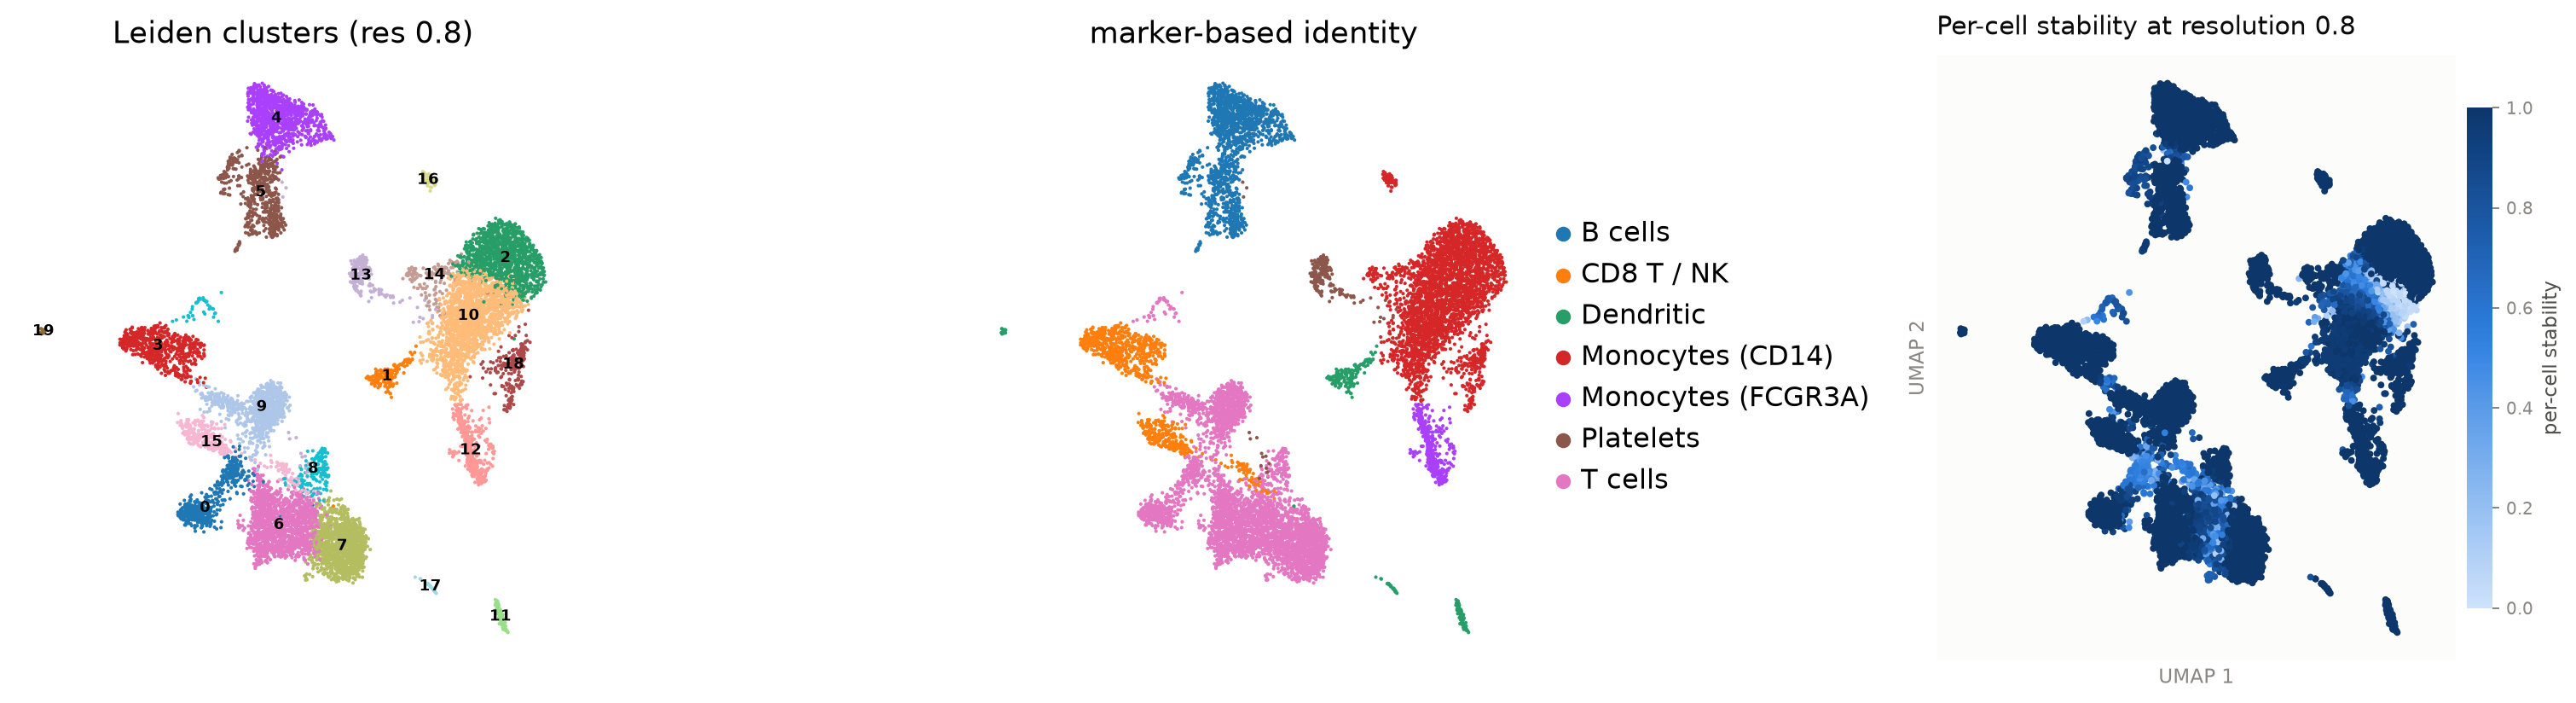

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sc.pl.umap(
    adata,
    color="leiden",
    ax=axes[0],
    show=False,
    legend_loc="on data",
    legend_fontsize=7,
    title=f"Leiden clusters (res {chosen})",
)
sc.pl.umap(
    adata, color="cell_type", ax=axes[1], show=False, title="marker-based identity"
)
scs.pl.stability_umap(adata, result, resolution=chosen, ax=axes[2])
plt.tight_layout()
plt.show()

**This is the picture worth taking away.** Instability is not spread evenly —
it sits at the **boundaries between clusters**, with the cores solid. The
cells whose assignment depends on which other cells you happened to sequence
are precisely the ones near a border the algorithm had to guess at.

## 8. What to do about a cluster that is not trustworthy

The question every stability tool raises and most leave hanging.

In [12]:
weak = block[block.jaccard_mean < 0.75].sort_values("jaccard_mean")
worst = weak.iloc[0]
print(
    f"Cluster {int(worst.cluster)}: {int(worst.n_cells)} cells, "
    f"{worst.identity}, stability {worst.jaccard_mean:.3f}\n"
)

# Where do its cells sit at a coarser resolution?
parents = result.reference_labels[0.6].astype(str).to_numpy()
mask = (adata.obs["leiden"].astype(str) == str(int(worst.cluster))).to_numpy()
print("At resolution 0.6 its cells belong to:")
print(
    pd.Series(parents[mask]).value_counts(normalize=True).head(3).round(2).to_string()
)

Cluster 8: 191 cells, T cells, stability 0.681

At resolution 0.6 its cells belong to:
4    0.8
3    0.2


So it is not a population that resampling fails to find. It is a
**subdivision** of a larger, stable cluster, and the line dividing them moves
every time you resample. Three defensible responses:

1. **Report it merged** at the coarser resolution, where the parent is stable.
2. **Keep it, and call it provisional** in the text, with the number.
3. **Get more cells** — small clusters are where the estimate is weakest.

What is *not* defensible is reporting it as a discovered population with no
caveat. Preventing that is the entire purpose of the package.

## 9. Write the results back, and publish

In [13]:
result.to_adata(adata)
[c for c in adata.obs.columns if c.startswith("stability_")]

['stability_res0.1',
 'stability_res0.2',
 'stability_res0.4',
 'stability_res0.6',
 'stability_res0.8',
 'stability_res1',
 'stability_res1.4']

In [14]:
trust = block[block.jaccard_mean >= 0.75]
print(
    f"At resolution {chosen}, {len(trust)} of {len(block)} clusters clear "
    f"Hennig's 0.75 threshold,"
)
print(
    f"covering {trust.n_cells.sum():,} of {block.n_cells.sum():,} cells "
    f"({100 * trust.n_cells.sum() / block.n_cells.sum():.0f}%).\n"
)
print(
    trust.groupby("identity", observed=True)
    .agg(clusters=("cluster", "size"), cells=("n_cells", "sum"))
    .sort_values("cells", ascending=False)
    .to_string()
)

At resolution 0.8, 16 of 20 clusters clear Hennig's 0.75 threshold,
covering 7,596 of 11,037 cells (69%).

                    clusters  cells
identity                           
T cells                    4   4122
B cells                    2   1576
CD8 T / NK                 1    579
Monocytes (CD14)           3    446
Monocytes (FCGR3A)         1    373
Dendritic                  4    287
Platelets                  1    213


## The sentence you would actually write

> Clustering was performed with Leiden at resolution 0.8. Cluster stability
> was assessed by the cluster-wise Jaccard measure of Hennig (2007) over 30
> subsamples of 80% of cells (`scstability`). 16 of 20 clusters exceeded the
> 0.75 stability threshold, covering 69% of cells; the remaining four, chiefly
> within the CD14⁺ monocyte compartment, fell in the 0.60–0.75 band and are
> reported as provisional.

That is defensible to a reviewer, and it came from one function call plus the
judgement in section 8.

---

**Caveats, stated plainly.** Stability is necessary, not sufficient: a
reproducible cluster can still be a doublet artefact or an uncorrected batch.
It cannot find "the true number of clusters" — a reproducible over-split is
still reproducible. And it measures *sampling* stability, not seed stability;
see the [README](../README.md) for how the two differ and when to prefer
`ClustAssessPy` instead.